In [1]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoModel
import boto3

model_storage_folder = 'downloaded_models'


In [2]:
def load_model_from_path(model_name, model_storage_folder):
    model_path = os.path.join(model_storage_folder, model_name)
    return AutoModel.from_pretrained(model_path)

In [3]:
def get_model_size(model_name, model_storage_folder):
    model_path = os.path.join(model_storage_folder, model_name)
    total_size = 0
    try:
        for dirpath, dirnames, filenames in os.walk(model_path):
            for f in filenames:
                fp = os.path.join(dirpath, f)
                total_size += os.path.getsize(fp)
        return total_size / (1024 * 1024)
    except Exception as e:
        print(f"Error calculating disk size for {model_name}: {e}")

def collect_model_sizes(model_list, model_storage_folder):
    model_sizes = []
    for model_name in model_list:
        size_mb = get_model_size(model_name, model_storage_folder)
        model_sizes.append({'model_name': model_name, 'size_mb': size_mb})
    return pd.DataFrame(model_sizes)


In [4]:
model_storage_folder = 'downloaded_models'
model_list = ["google_gemma-2b-it", "meta-llama_Llama-2-7b-hf", "mistralai_Mistral-7B-Instruct-v0.2"]
model_sizes = collect_model_sizes(model_list, model_storage_folder)
print(model_sizes)


                           model_name       size_mb
0                  google_gemma-2b-it   9560.318702
1            meta-llama_Llama-2-7b-hf  25205.067694
2  mistralai_Mistral-7B-Instruct-v0.2  27125.067694


In [5]:
import torch.nn as nn
def analyze_model_stats(model, model_name, model_storage_folder):
    try:
        print(f"Starting model analysis for {model_name}...")
        total_parameters = sum(p.numel() for p in model.parameters())
        total_layers = sum(1 for _ in model.modules() if isinstance(_, nn.Linear) or isinstance(_, nn.Conv2d))
        model_size_mb = get_model_size(model_name, model_storage_folder) 

        stats = {
            'model_size_mb': model_size_mb,
            'total_parameters': total_parameters,
            'total_layers': total_layers
        }
        print("Completed model analysis.")
        return stats
    except Exception as e:
        print(f"Error during analysis of {model_name}: {e}")

def collect_model_stats(model_list, model_storage_folder):
    model_stats = []
    
    for model_name in model_list:
        model = load_model_from_path(model_name, model_storage_folder)
        stats = analyze_model_stats(model, model_name, model_storage_folder)
        stats['model_name'] = model_name
        model_stats.append(stats)
    
    return pd.DataFrame(model_stats)


In [6]:
model_storage_folder = 'downloaded_models' 
model_list = ["google_gemma-2b-it", "meta-llama_Llama-2-7b-hf", "mistralai_Mistral-7B-Instruct-v0.2"]
model_statistics = collect_model_stats(model_list, model_storage_folder)

Gemma's activation function should be approximate GeLU and not exact GeLU.
Changing the activation function to `gelu_pytorch_tanh`.if you want to use the legacy `gelu`, edit the `model.config` to set `hidden_activation=gelu`   instead of `hidden_act`. See https://github.com/huggingface/transformers/pull/29402 for more details.


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Starting model analysis for google_gemma-2b-it...
Completed model analysis.


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Starting model analysis for meta-llama_Llama-2-7b-hf...
Completed model analysis.


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Starting model analysis for mistralai_Mistral-7B-Instruct-v0.2...
Completed model analysis.


In [8]:
print(model_statistics)

   model_size_mb  total_parameters  total_layers  \
0    9560.318702        2506172416           126   
1   25205.067694        6607343616           224   
2   27125.067694        7110660096           224   

                           model_name  
0                  google_gemma-2b-it  
1            meta-llama_Llama-2-7b-hf  
2  mistralai_Mistral-7B-Instruct-v0.2  


In [9]:
def calculate_cdf(data):
    data_sorted = np.sort(data)
    cdf = np.arange(1, len(data_sorted) + 1) / float(len(data_sorted))
    return data_sorted, cdf

size_sorted, size_cdf = calculate_cdf(model_statistics['model_size_mb'])
params_sorted, params_cdf = calculate_cdf(model_statistics['total_parameters'])
layers_sorted, layers_cdf = calculate_cdf(model_statistics['total_layers'])

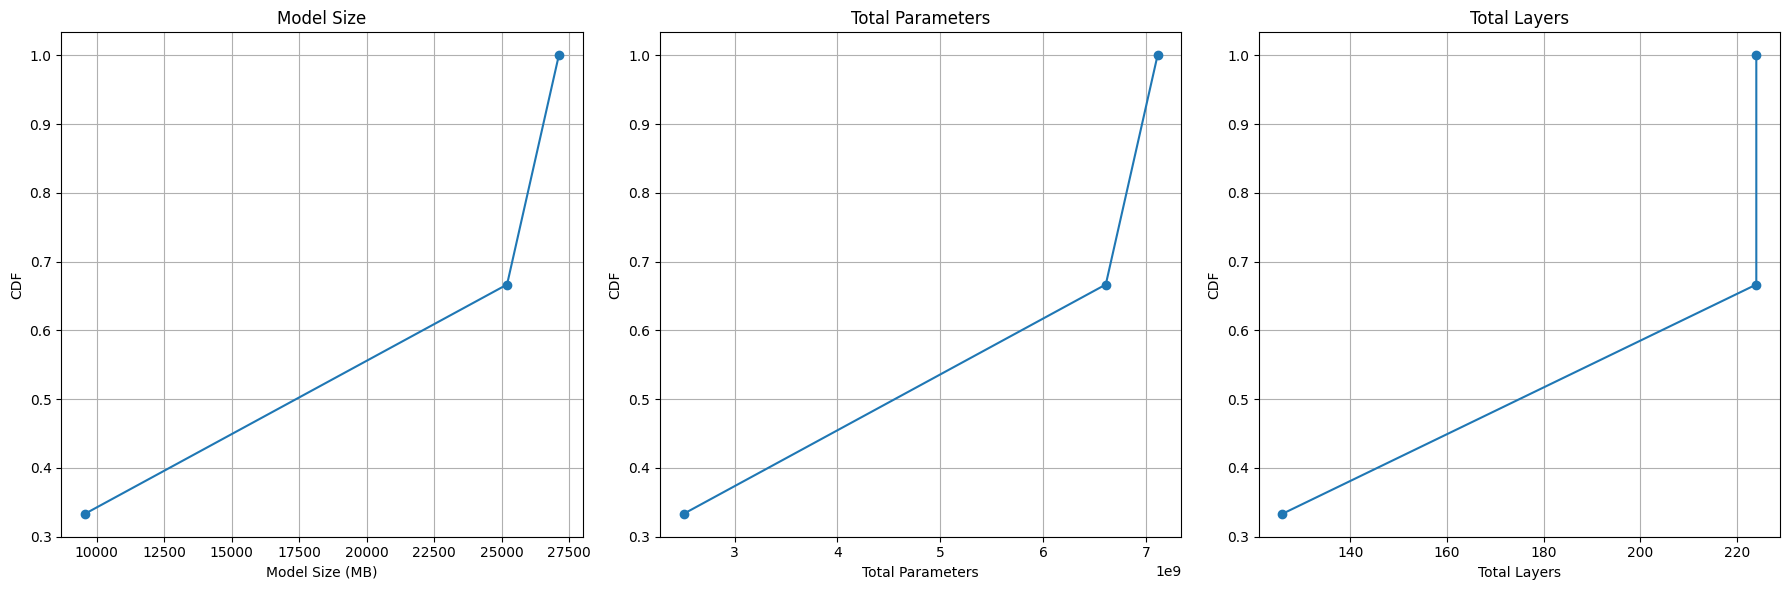

In [10]:
plt.figure(figsize=(18, 6))

# model size in MB
plt.subplot(1, 3, 1)
plt.plot(size_sorted, size_cdf, marker='o')
plt.xlabel('Model Size (MB)')
plt.ylabel('CDF')
plt.title('Model Size')
plt.grid(True)

# number of parameters
plt.subplot(1, 3, 2)
plt.plot(params_sorted, params_cdf, marker='o')
plt.xlabel('Total Parameters')
plt.ylabel('CDF')
plt.title('Total Parameters')
plt.grid(True)

# layer count
plt.subplot(1, 3, 3)
plt.plot(layers_sorted, layers_cdf, marker='o')
plt.xlabel('Total Layers')
plt.ylabel('CDF')
plt.title('Total Layers')
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Collect all parameters
model_list = ["google_gemma-2b-it"]
#, "meta-llama_Llama-2-7b-hf", "mistralai_Mistral-7B-Instruct-v0.2"
all_parameters = np.array([])
for model_name in model_list:
    model = load_model_from_path(model_name, model_storage_folder)
    params = np.concatenate([p.data.cpu().numpy().flatten() for p in model.parameters()])
    all_parameters = np.concatenate((all_parameters, params))


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

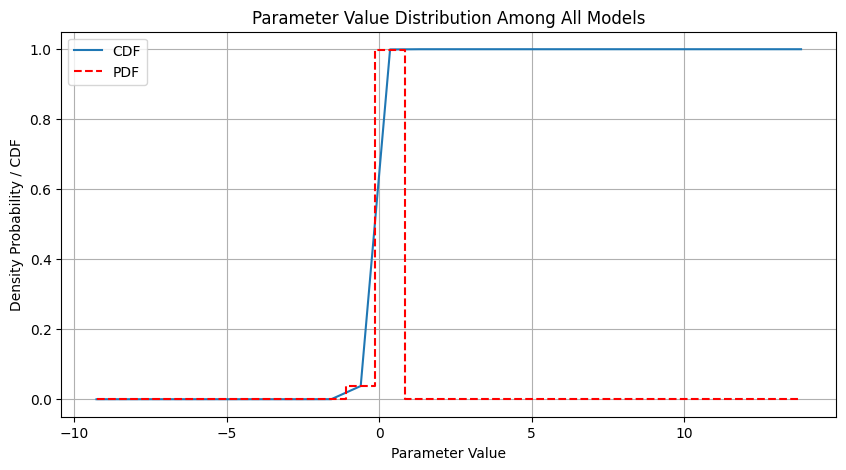

In [15]:
# Parameter value distribution
pdf, bins = np.histogram(all_parameters, bins=25, density=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

cdf = np.cumsum(pdf) * np.diff(bins)

# Plot PDF and CDF for parameter distribution
plt.figure(figsize=(10, 5))
plt.plot(bin_centers, cdf, label='CDF')
plt.plot(bin_centers, pdf, drawstyle='steps-mid', linestyle='--', color='red', label='PDF')
plt.xlabel('Parameter Value')
plt.ylabel('Density Probability / CDF')
plt.title('Parameter Value Distribution Among All Models')
plt.legend(loc='best')
plt.grid(True)
plt.show()


In [9]:
def analyze_model_parameters(all_parameters):
    try:
        print("Starting parameter analysis.")
        # model_params = {name: param for name, param in model.named_parameters()}
        # all_params = np.concatenate([p.data.cpu().numpy().flatten() for p in model_params.values()])
        all_params = all_parameters
        
        stats = {
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'total_layers': sum(1 for _ in model.parameters()),
            'mean': np.mean(all_params),
            'min': np.min(all_params),
            'max': np.max(all_params),
            'median': np.median(all_params),
            'percent_within_1_std': np.mean((all_params >= -1) & (all_params <= 1)) * 100
        }
        print("Completed parameter analysis.")
        return stats
    except Exception as e:
        print(f"Error during analysis: {e}")
    finally:
        del model_params, all_params
        gc.collect()
        print("Cleaned up memory.")

def collect_params_stats(model_list, model_storage_folder, all_parameters):
    model_stats = []
    
    for model_name in model_list:
        #model = load_model_from_path(model_name, model_storage_folder)
        stats = analyze_model_parameters(all_parameters) 
        stats['model_name'] = model_name
        model_stats.append(stats)
    
    return pd.DataFrame(model_stats)

In [ ]:
model_list = ["google_gemma-2b-it"]
# , "meta-llama_Llama-2-7b-hf", "mistralai_Mistral-7B-Instruct-v0.2"
model_statistics = collect_params_stats(model_list, model_storage_folder, all_parameters)
print(model_statistics)

Starting parameter analysis...
